# Big Data Analysis and Application Experiment 1

**Experiment Topic:** Data Preparation with pandas  
**School:** Hubei University  
**Class:** Software Engineering 2402  
**Student Name:** Qin Tian  
**Student ID:** 202431123002054
**Instructor:** Li Jie


# 1. Problem Description

This experiment uses employee attrition data from pfm_train.csv and pfm_test.csv. The task in this part is not the final prediction model yet. What I need to do first is prepare the raw data for the later logistic regression work.

In the original files, the training set contains the target column Attrition, while the test set does not. So the main problem is not hard to see: before modeling, I need to check the dataset structure, find useless columns, handle text features that can not go into the model directly, and keep the processed train and test data in the same feature format.


# 2. Basic Approach

First, I read the two csv files with pandas and check their shape, column types, missing values, duplicate rows, and constant columns. This step helps me know what kind of cleaning is really needed, instead of changing the data without checking it first.

After the inspection, I remove Over18, StandardHours, and EmployeeNumber, because they do not provide useful information for prediction. Then I use pd.get_dummies() to encode the categorical columns, split the training data into X_train and y_train, and use reindex() to keep the test set aligned with the training feature columns. In the last step, I standardize the original numeric features by StandardScaler, fitting on the training set first and applying the same rule to the test set.


# 3. Source Code

The following code records the full data preparation process used in this experiment.


The code part is kept step by step, so each check and processing action can be seen clearly.


## 3.1 Read the raw csv files

This step reads the two csv files and takes a quick look at the dataset size and the first few rows.


In [10]:
# use pandas to read the csv files
import pandas as pd

# this one is for scaling the numeric features later
from sklearn.preprocessing import StandardScaler

# read train data and test data
train = pd.read_csv("pfm_train.csv")
test = pd.read_csv("pfm_test.csv")

# just check the size first
print("train shape:", train.shape)
print("test shape:", test.shape)

# have a look of the first few rows
train.head()

train shape: (1100, 31)
test shape: (350, 30)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,37,0,Travel_Rarely,Research & Development,1,4,Life Sciences,77,1,Male,...,3,80,1,7,2,4,7,5,0,7
1,54,0,Travel_Frequently,Research & Development,1,4,Life Sciences,1245,4,Female,...,1,80,1,33,2,1,5,4,1,4
2,34,1,Travel_Frequently,Research & Development,7,3,Life Sciences,147,1,Male,...,4,80,0,9,3,3,9,7,0,6
3,39,0,Travel_Rarely,Research & Development,1,1,Life Sciences,1026,4,Female,...,3,80,1,21,3,3,21,6,11,8
4,28,1,Travel_Frequently,Research & Development,1,3,Medical,1111,1,Male,...,1,80,2,1,2,3,1,0,0,0


## 3.2 Check basic information and missing values

This step checks column types and missing values, because the later cleaning method depends on them.


In [11]:
# check basic info of train set
print("=== train info ===")
train.info()

# also check the test set
print("\n=== test info ===")
test.info()

# see if there is any missing values in train
print("\n=== missing values in train ===")
print(train.isnull().sum())

# same thing for test
print("\n=== missing values in test ===")
print(test.isnull().sum())

=== train info ===
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1100 non-null   int64
 1   Attrition                 1100 non-null   int64
 2   BusinessTravel            1100 non-null   str  
 3   Department                1100 non-null   str  
 4   DistanceFromHome          1100 non-null   int64
 5   Education                 1100 non-null   int64
 6   EducationField            1100 non-null   str  
 7   EmployeeNumber            1100 non-null   int64
 8   EnvironmentSatisfaction   1100 non-null   int64
 9   Gender                    1100 non-null   str  
 10  JobInvolvement            1100 non-null   int64
 11  JobLevel                  1100 non-null   int64
 12  JobRole                   1100 non-null   str  
 13  JobSatisfaction           1100 non-null   int64
 14  MaritalStatus             1100 n

## 3.3 Check duplicate rows and constant columns

Duplicate rows may affect the later model, and constant columns do not provide real information.


In [12]:
# check duplicate rows first
print("duplicate rows in train:", train.duplicated().sum())
print("duplicate rows in test:", test.duplicated().sum())

# find the columns which only have one value
const_train = [col for col in train.columns if train[col].nunique(dropna=False) == 1]
const_test = [col for col in test.columns if test[col].nunique(dropna=False) == 1]

# print them out
print("constant cols in train:", const_train)
print("constant cols in test:", const_test)

duplicate rows in train: 0
duplicate rows in test: 0
constant cols in train: ['Over18', 'StandardHours']
constant cols in test: ['Over18', 'StandardHours']


## 3.4 Check the label and categorical columns

Here I check the label distribution and the raw text columns, so I can decide the later encoding method.


In [13]:
# see the target label distribution
print("attrition counts:")
print(train["Attrition"].value_counts())

# find all categorical columns in raw data
cat_cols_raw = train.select_dtypes(include="object").columns.tolist()
print("\nraw categorical cols:", cat_cols_raw)

# check each category values
for col in cat_cols_raw:
    print(f"\nvalue counts of {col}:")
    print(train[col].value_counts())

attrition counts:
Attrition
0    922
1    178
Name: count, dtype: int64

raw categorical cols: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

value counts of BusinessTravel:
BusinessTravel
Travel_Rarely        787
Travel_Frequently    205
Non-Travel           108
Name: count, dtype: int64

value counts of Department:
Department
Research & Development    727
Sales                     331
Human Resources            42
Name: count, dtype: int64

value counts of EducationField:
EducationField
Life Sciences       462
Medical             337
Marketing           127
Technical Degree     92
Other                63
Human Resources      19
Name: count, dtype: int64

value counts of Gender:
Gender
Male      653
Female    447
Name: count, dtype: int64

value counts of JobRole:
JobRole
Sales Executive              247
Research Scientist           221
Laboratory Technician        205
Manufacturing Director       101
Healthcare Represen

C:\Users\rober\AppData\Local\Temp\ipykernel_30896\1742703896.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_raw = train.select_dtypes(include="object").columns.tolist()


## 3.5 Drop useless columns

According to the previous check, Over18, StandardHours, and EmployeeNumber are removed in this step.


In [14]:
# copy the data first, so the raw one not be changed
train_clean = train.copy()
test_clean = test.copy()

# these columns are not useful, so remove them
# Over18 and StandardHours are basically same value
# EmployeeNumber is just id
drop_cols = ["Over18", "StandardHours", "EmployeeNumber"]

# drop these columns in both train and test
train_clean = train_clean.drop(columns=drop_cols)
test_clean = test_clean.drop(columns=drop_cols)

# check the shape after dropping
print("train_clean shape:", train_clean.shape)
print("test_clean shape:", test_clean.shape)

train_clean shape: (1100, 28)
test_clean shape: (350, 27)


## 3.6 Encode categorical features

Text columns are converted into dummy variables here, so they can be used by the later model.


In [15]:
# get the categorical columns after dropping useless ones
cat_cols = train_clean.select_dtypes(include="object").columns.tolist()
print("categorical cols after drop:", cat_cols)

# do one-hot encoding for categorical features
# drop_first=True to avoid some repeated dummy columns
train_encoded = pd.get_dummies(train_clean, columns=cat_cols, drop_first=True)
test_encoded = pd.get_dummies(test_clean, columns=cat_cols, drop_first=True)

# split x and y from training data
X_train = train_encoded.drop(columns="Attrition")
y_train = train_encoded["Attrition"]

# make test columns same with train columns
# if some column is missing in test, fill it by 0
X_test = test_encoded.reindex(columns=X_train.columns, fill_value=0)

# find bool type columns
bool_cols_train = X_train.select_dtypes(include="bool").columns
bool_cols_test = X_test.select_dtypes(include="bool").columns

# change bool to int, maybe better for model later
X_train[bool_cols_train] = X_train[bool_cols_train].astype(int)
X_test[bool_cols_test] = X_test[bool_cols_test].astype(int)

# check shape after encoding
print("encoded train shape:", train_encoded.shape)
print("encoded test shape:", test_encoded.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

categorical cols after drop: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
encoded train shape: (1100, 42)
encoded test shape: (350, 41)
X_train shape: (1100, 41)
X_test shape: (350, 41)


C:\Users\rober\AppData\Local\Temp\ipykernel_30896\545202335.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_clean.select_dtypes(include="object").columns.tolist()


## 3.7 Scale numeric features

Only the original numeric columns are standardized in this step. The dummy columns are left as 0 and 1.


In [16]:
# pick numeric columns for scaling
# do not include the target column
num_cols = train_clean.select_dtypes(exclude="object").columns.tolist()
num_cols.remove("Attrition")

# print these numeric columns
print("scaled numeric cols:", num_cols)

# create the scaler
scaler = StandardScaler()

# fit on train data first, then transform it
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# use the same scaler on test data
X_test[num_cols] = scaler.transform(X_test[num_cols])

# look the processed train data
X_train.head()

scaled numeric cols: ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.000101,-1.028598,1.054313,-1.572091,-1.035216,-0.049260,0.240954,-0.104096,-0.671072,0.762229,...,0,0,1,0,0,0,0,0,0,0
1,1.882064,-1.028598,1.054313,1.161260,0.381124,0.853837,0.240954,0.852589,1.720437,0.486513,...,0,0,1,0,0,0,0,0,0,0
2,-0.332010,-0.296263,0.075626,-1.572091,-2.451557,-0.049260,0.240954,-0.086910,-0.671072,2.416525,...,1,0,0,0,0,0,0,0,1,1
3,0.221508,-1.028598,-1.881748,1.161260,-1.035216,1.756934,1.142483,1.327855,-0.671072,0.210797,...,0,0,1,0,0,0,0,1,0,0
4,-0.996233,-1.028598,0.075626,-1.572091,-1.035216,-0.952357,-0.660575,-0.824846,-0.671072,-0.064919,...,1,0,0,0,0,0,0,0,0,0


## 3.8 Final check of prepared data

This step checks the final shape of the processed data and confirms that no missing value is left.


In [17]:
# final check of the shapes
print("final X_train shape:", X_train.shape)
print("final y_train shape:", y_train.shape)
print("final X_test shape:", X_test.shape)

# see if there is still missing values
print("missing values in X_train:", X_train.isnull().sum().sum())
print("missing values in X_test:", X_test.isnull().sum().sum())

# check the final data types
print("\nX_train dtype summary:")
print(X_train.dtypes.value_counts())

final X_train shape: (1100, 41)
final y_train shape: (1100,)
final X_test shape: (350, 41)
missing values in X_train: 0
missing values in X_test: 0

X_train dtype summary:
int64      21
float64    20
Name: count, dtype: int64


## 3.9 Prepare the final modeling matrix

In [18]:
from pathlib import Path

# save the preprocessing output for the later linear-model practice
# always write to the sibling experiment folder, so the files can be regenerated anytime
output_dir = Path.cwd().parent / "实验二"
output_dir.mkdir(parents=True, exist_ok=True)

X_train.to_csv(output_dir / "X_train_preprocessed.csv", index=False)
y_train.to_frame(name="Attrition").to_csv(output_dir / "y_train_preprocessed.csv", index=False)
X_test.to_csv(output_dir / "X_test_preprocessed.csv", index=False)

print("saved:", output_dir / "X_train_preprocessed.csv")
print("saved:", output_dir / "y_train_preprocessed.csv")
print("saved:", output_dir / "X_test_preprocessed.csv")

saved: d:\daima\cursor\大数据分析\实验二\X_train_preprocessed.csv
saved: d:\daima\cursor\大数据分析\实验二\y_train_preprocessed.csv
saved: d:\daima\cursor\大数据分析\实验二\X_test_preprocessed.csv


# 4. Visualization and Model Code

## 4.1 Prepare the validation split and output folders

In [19]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

if "train" not in globals():
    train = pd.read_csv("pfm_train.csv")

if "X_train" in globals() and "y_train" in globals():
    prepared_X = X_train.copy()
    prepared_y = pd.Series(y_train).copy()
else:
    train_clean = train.drop(columns=["Over18", "StandardHours", "EmployeeNumber"]).copy()
    cat_cols = train_clean.select_dtypes(include="object").columns.tolist()
    train_encoded = pd.get_dummies(train_clean, columns=cat_cols, drop_first=True)
    prepared_X = train_encoded.drop(columns="Attrition")
    prepared_y = train_encoded["Attrition"]
    bool_cols = prepared_X.select_dtypes(include="bool").columns
    prepared_X[bool_cols] = prepared_X[bool_cols].astype(int)

prepared_y = pd.Series(prepared_y, name="Attrition")

X_fit, X_valid, y_fit, y_valid = train_test_split(
    prepared_X,
    prepared_y,
    test_size=0.25,
    random_state=42,
    stratify=prepared_y,
)

fig_dir = Path("experiment1_figures")
fig_dir.mkdir(exist_ok=True)

print("prepared_X shape:", prepared_X.shape)
print("prepared_y shape:", prepared_y.shape)
print("X_fit shape:", X_fit.shape)
print("X_valid shape:", X_valid.shape)
print("validation label distribution:")
print(y_valid.value_counts(normalize=True).round(4))

prepared_X shape: (1100, 41)
prepared_y shape: (1100,)
X_fit shape: (825, 41)
X_valid shape: (275, 41)
validation label distribution:
Attrition
0    0.84
1    0.16
Name: proportion, dtype: float64


## 4.2 Draw the main figures

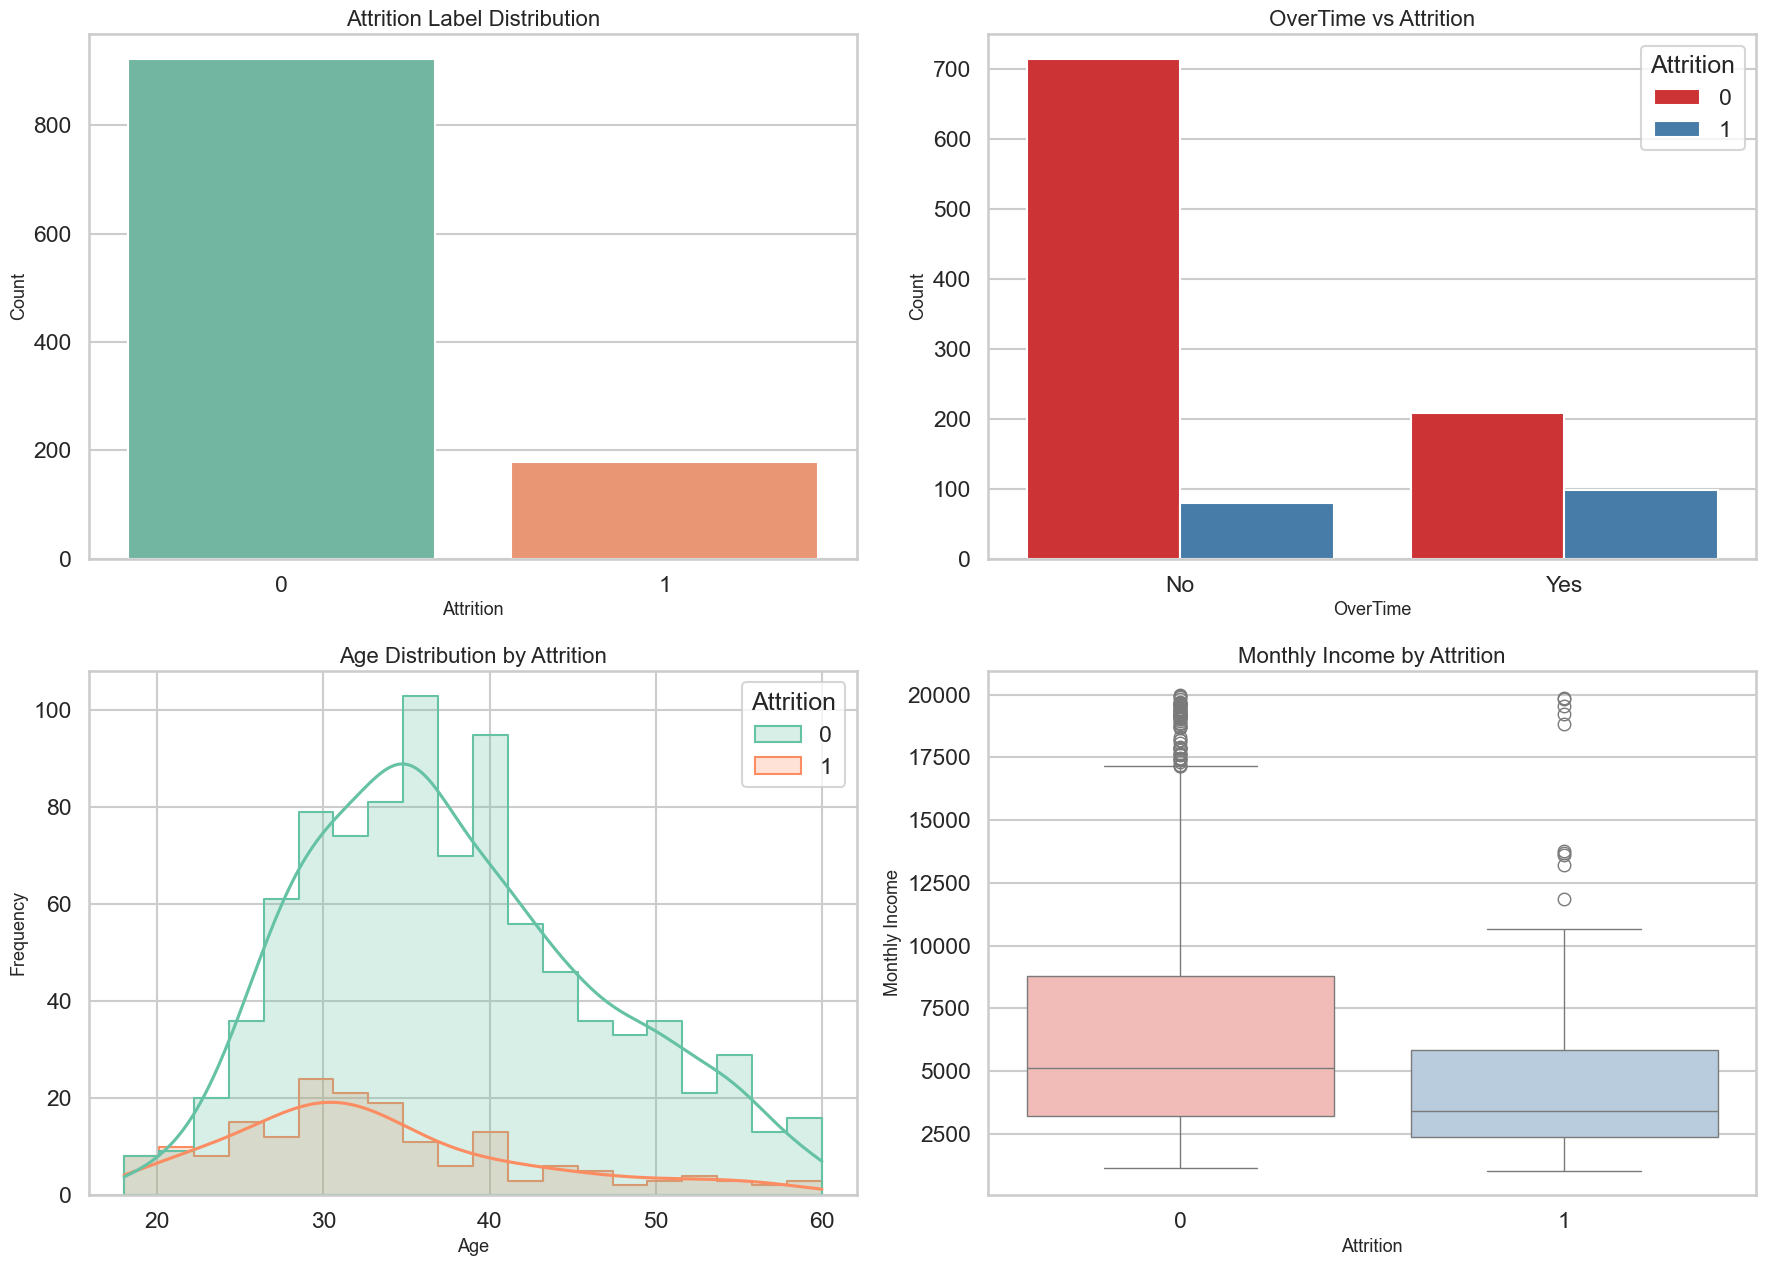

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

sns.countplot(data=train, x="Attrition", hue="Attrition", palette="Set2", ax=axes[0, 0], legend=False)
axes[0, 0].set_title("Attrition Label Distribution")
axes[0, 0].set_xlabel("Attrition")
axes[0, 0].set_ylabel("Count")

sns.countplot(data=train, x="OverTime", hue="Attrition", palette="Set1", ax=axes[0, 1])
axes[0, 1].set_title("OverTime vs Attrition")
axes[0, 1].set_xlabel("OverTime")
axes[0, 1].set_ylabel("Count")

sns.histplot(data=train, x="Age", hue="Attrition", kde=True, bins=20, palette="Set2", ax=axes[1, 0], element="step")
axes[1, 0].set_title("Age Distribution by Attrition")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Frequency")

sns.boxplot(data=train, x="Attrition", y="MonthlyIncome", hue="Attrition", palette="Pastel1", ax=axes[1, 1], legend=False)
axes[1, 1].set_title("Monthly Income by Attrition")
axes[1, 1].set_xlabel("Attrition")
axes[1, 1].set_ylabel("Monthly Income")

plt.tight_layout()
fig.savefig(fig_dir / "figure_01_label_and_basic_patterns.png", dpi=200, bbox_inches="tight")
plt.show()

C:\Users\rober\AppData\Local\Temp\ipykernel_30896\1488354625.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\rober\AppData\Local\Temp\ipykernel_30896\1488354625.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\rober\AppData\Local\Temp\ipykernel_30896\1488354625.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


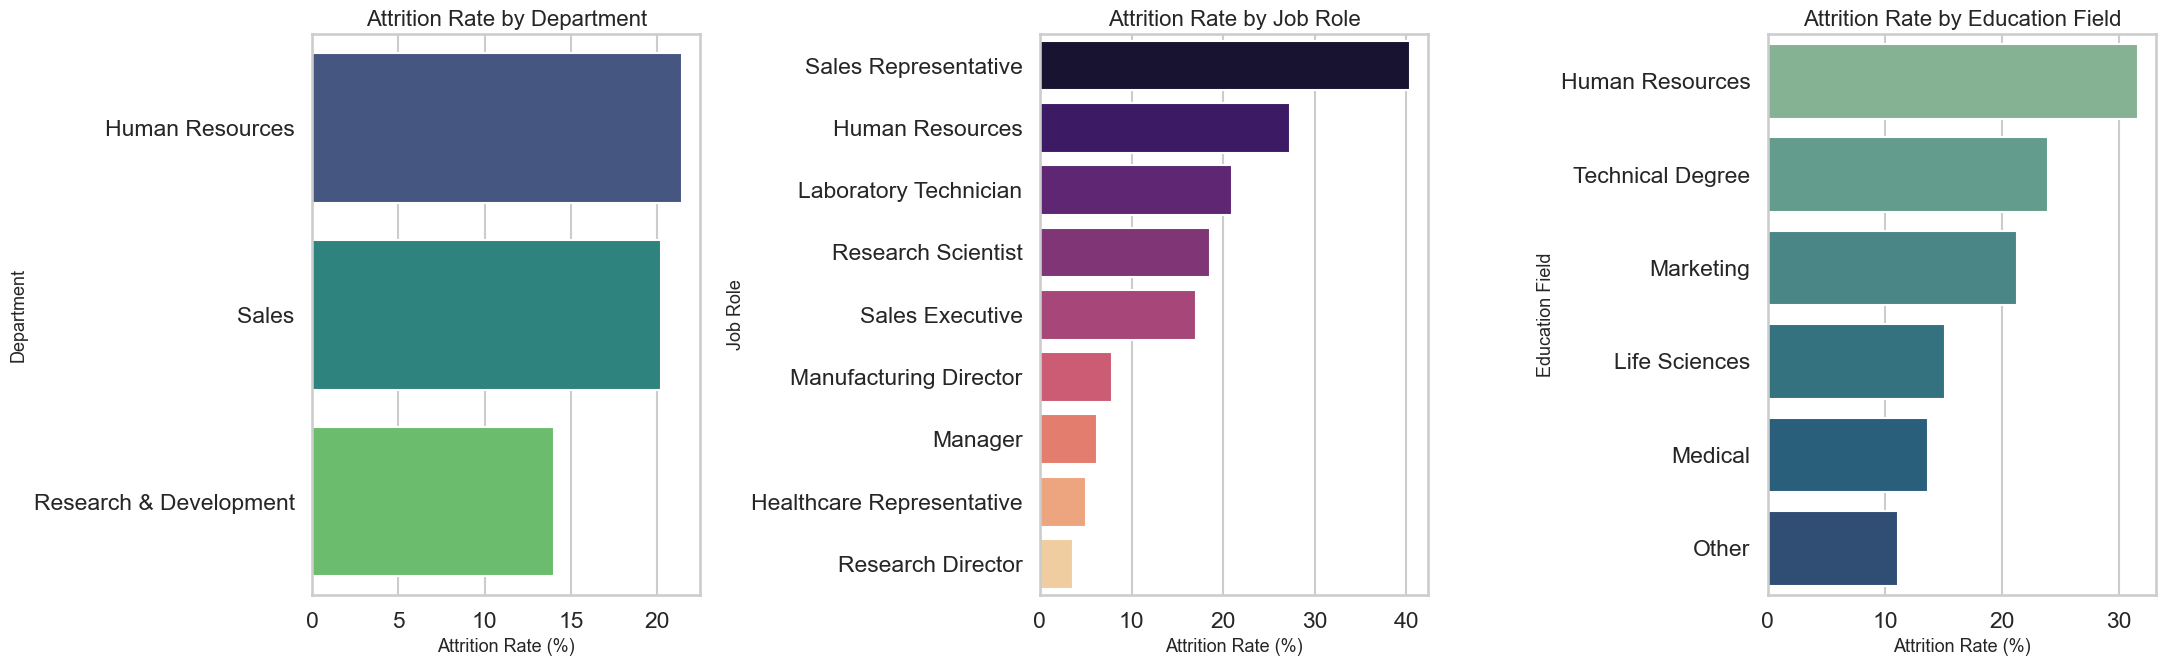

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

department_rate = (
    train.groupby("Department")["Attrition"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)
sns.barplot(
    x=department_rate.values,
    y=department_rate.index,
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Attrition Rate by Department")
axes[0].set_xlabel("Attrition Rate (%)")
axes[0].set_ylabel("Department")

jobrole_rate = (
    train.groupby("JobRole")["Attrition"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)
sns.barplot(
    x=jobrole_rate.values,
    y=jobrole_rate.index,
    palette="magma",
    ax=axes[1],
)
axes[1].set_title("Attrition Rate by Job Role")
axes[1].set_xlabel("Attrition Rate (%)")
axes[1].set_ylabel("Job Role")

education_rate = (
    train.groupby("EducationField")["Attrition"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)
sns.barplot(
    x=education_rate.values,
    y=education_rate.index,
    palette="crest",
    ax=axes[2],
)
axes[2].set_title("Attrition Rate by Education Field")
axes[2].set_xlabel("Attrition Rate (%)")
axes[2].set_ylabel("Education Field")

plt.tight_layout()
fig.savefig(fig_dir / "figure_02_attrition_rate_by_category.png", dpi=200, bbox_inches="tight")
plt.show()

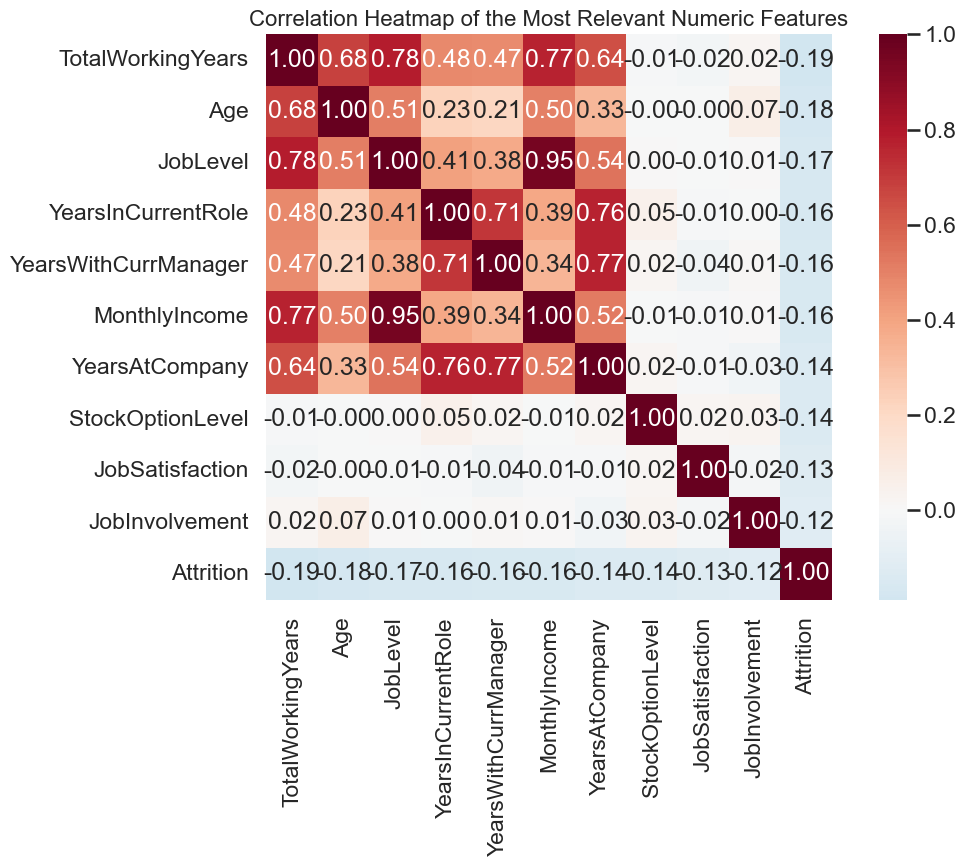

Top numeric correlations with Attrition:
TotalWorkingYears      -0.187922
Age                    -0.175393
JobLevel               -0.168775
YearsInCurrentRole     -0.163059
YearsWithCurrManager   -0.158558
MonthlyIncome          -0.155521
YearsAtCompany         -0.143697
StockOptionLevel       -0.138498
JobSatisfaction        -0.125568
JobInvolvement         -0.122722
Name: Attrition, dtype: float64


In [22]:
corr_source = train.select_dtypes(exclude="object").copy()
corr_target = corr_source.corr(numeric_only=True)["Attrition"].drop("Attrition")
top_corr_features = corr_target.abs().sort_values(ascending=False).head(10).index.tolist()
heatmap_columns = top_corr_features + ["Attrition"]

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_source[heatmap_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
)
plt.title("Correlation Heatmap of the Most Relevant Numeric Features")
plt.tight_layout()
plt.savefig(fig_dir / "figure_03_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

print("Top numeric correlations with Attrition:")
print(corr_target.sort_values(key=lambda s: s.abs(), ascending=False).head(10))

## 4.3 Train multiple models and save the outputs

In [23]:
models = {
    "Logistic Regression (L2)": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    ),
    "Logistic Regression (L1)": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        penalty="l1",
        solver="liblinear",
        random_state=42,
    ),
    "SGD Log-Loss": SGDClassifier(
        loss="log_loss",
        class_weight="balanced",
        max_iter=3000,
        tol=1e-4,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
    ),
}

model_results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_fit, y_fit)
    fitted_models[name] = model

    y_pred = model.predict(X_valid)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_valid)[:, 1]
    else:
        raw_score = model.decision_function(X_valid)
        y_score = 1 / (1 + np.exp(-raw_score))

    model_results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_valid, y_pred),
            "Precision": precision_score(y_valid, y_pred),
            "Recall": recall_score(y_valid, y_pred),
            "F1": f1_score(y_valid, y_pred),
            "ROC_AUC": roc_auc_score(y_valid, y_score),
        }
    )

metrics_df = pd.DataFrame(model_results).sort_values(
    by=["ROC_AUC", "F1"],
    ascending=False,
).reset_index(drop=True)

metrics_df.to_csv("model_metrics.csv", index=False)
metrics_df.style.format(
    {
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
    }
)

d:\kaifagongju\Anaconda\envs\DL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\kaifagongju\Anaconda\envs\DL\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (L2),0.8000,0.4267,0.7273,0.5378,0.8081
1,Random Forest,0.8582,0.6471,0.2500,0.3607,0.8051
2,Logistic Regression (L1),0.7818,0.3974,0.7045,0.5082,0.8044
3,SGD Log-Loss,0.7455,0.3289,0.5682,0.4167,0.7559


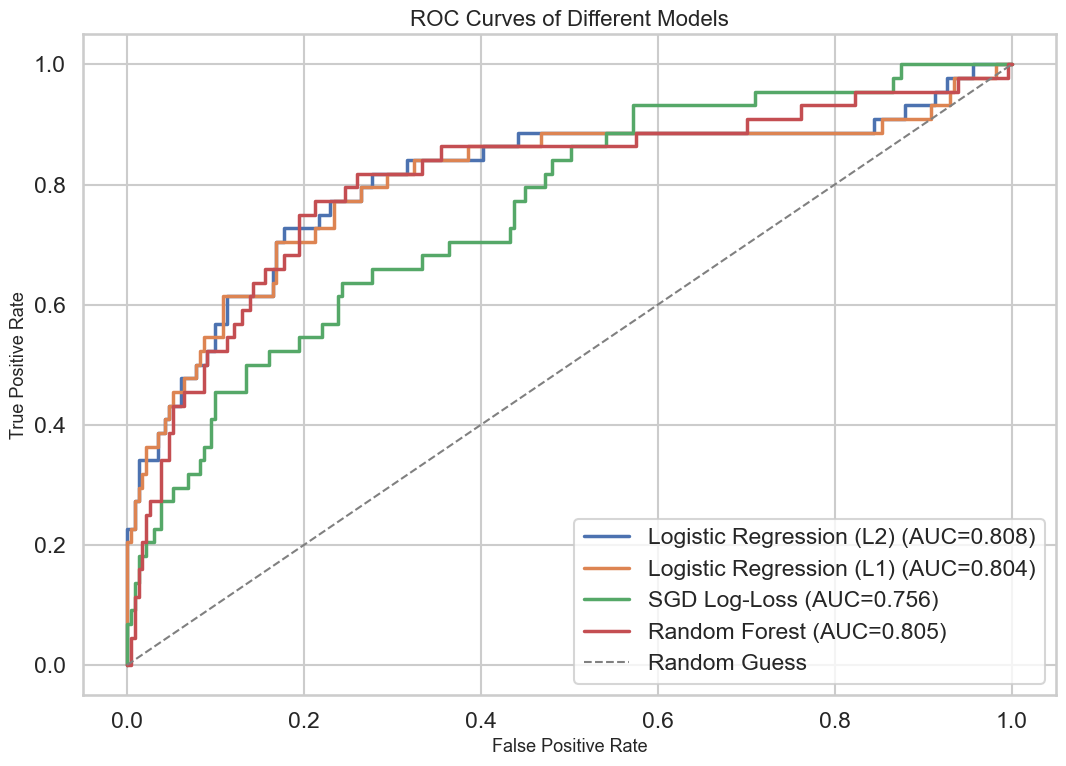

In [24]:
plt.figure(figsize=(11, 8))

for name, model in fitted_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_valid)[:, 1]
    else:
        raw_score = model.decision_function(X_valid)
        y_score = 1 / (1 + np.exp(-raw_score))

    fpr, tpr, _ = roc_curve(y_valid, y_score)
    auc_value = roc_auc_score(y_valid, y_score)
    plt.plot(fpr, tpr, linewidth=2.5, label=f"{name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Random Guess")
plt.title("ROC Curves of Different Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(fig_dir / "figure_04_roc_curves.png", dpi=200, bbox_inches="tight")
plt.show()

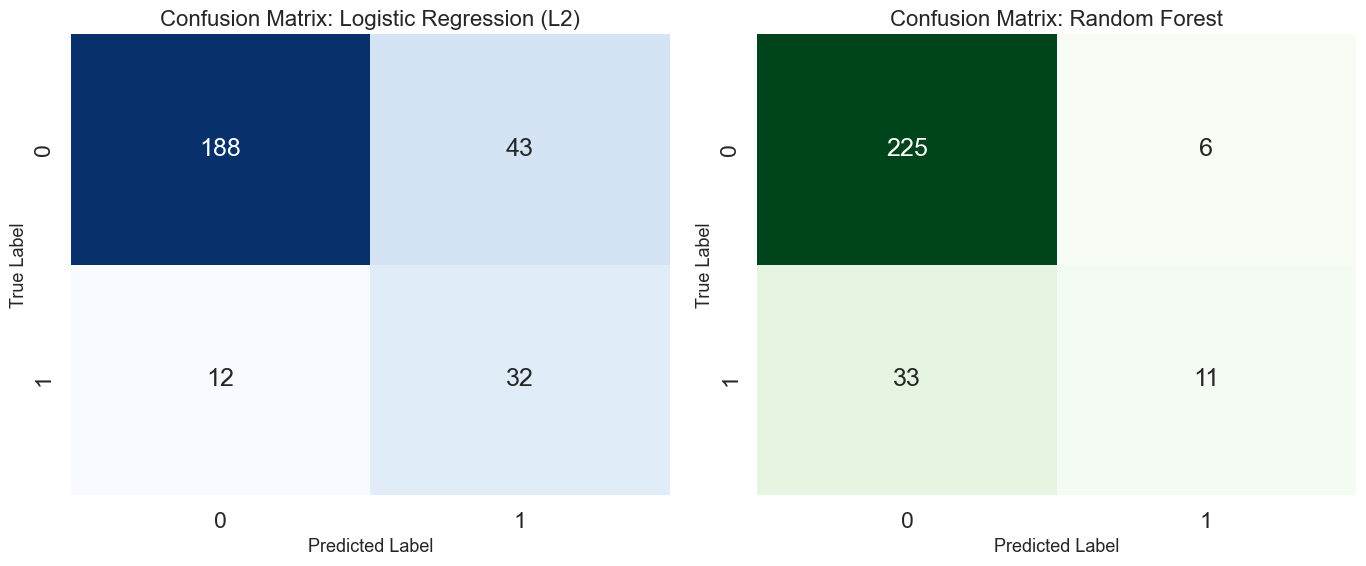

In [25]:
best_log_model = fitted_models["Logistic Regression (L2)"]
rf_model = fitted_models["Random Forest"]

cm_log = confusion_matrix(y_valid, best_log_model.predict(X_valid))
cm_rf = confusion_matrix(y_valid, rf_model.predict(X_valid))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix: Logistic Regression (L2)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix: Random Forest")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
fig.savefig(fig_dir / "figure_05_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

C:\Users\rober\AppData\Local\Temp\ipykernel_30896\3340413172.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\rober\AppData\Local\Temp\ipykernel_30896\3340413172.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


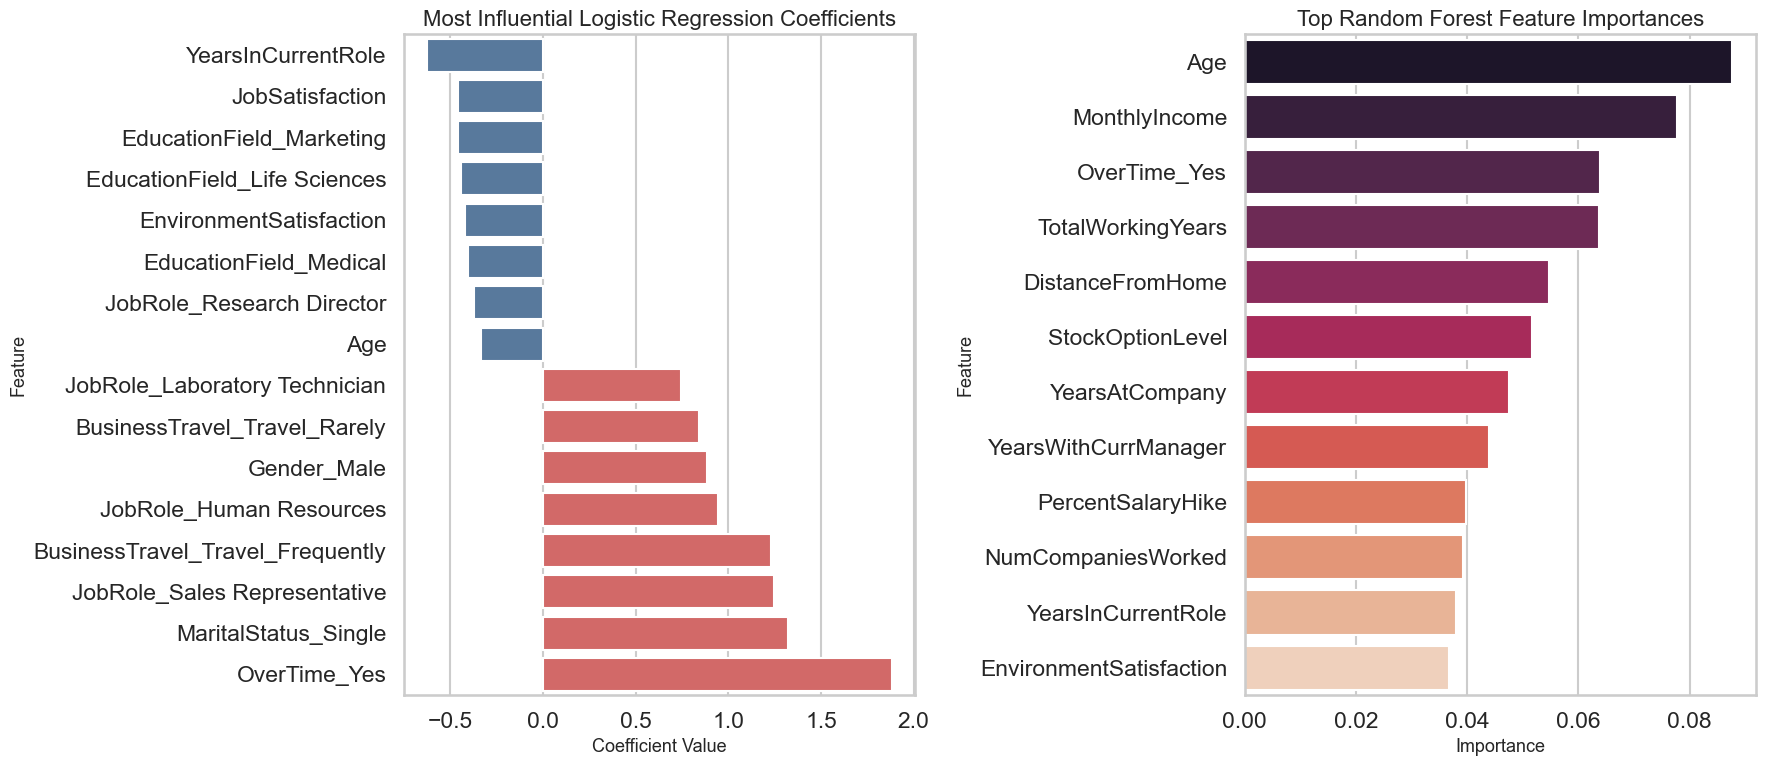

Top positive logistic coefficients:
OverTime_Yes                        1.881668
MaritalStatus_Single                1.319553
JobRole_Sales Representative        1.247747
BusinessTravel_Travel_Frequently    1.231700
JobRole_Human Resources             0.943837
Gender_Male                         0.883100
BusinessTravel_Travel_Rarely        0.841504
JobRole_Laboratory Technician       0.743538
dtype: float64

Top negative logistic coefficients:
YearsInCurrentRole             -0.627042
JobSatisfaction                -0.457929
EducationField_Marketing       -0.457115
EducationField_Life Sciences   -0.444256
EnvironmentSatisfaction        -0.420768
EducationField_Medical         -0.403998
JobRole_Research Director      -0.373545
Age                            -0.335217
dtype: float64


In [26]:
log_coef = (
    pd.Series(best_log_model.coef_[0], index=prepared_X.columns)
    .sort_values()
)
top_negative = log_coef.head(8).sort_values(ascending=True)
top_positive = log_coef.tail(8).sort_values(ascending=False)

rf_importance = (
    pd.Series(rf_model.feature_importances_, index=prepared_X.columns)
    .sort_values(ascending=False)
    .head(12)
)

top_positive.to_csv("logistic_top_positive_coefficients.csv", header=["coefficient"])
top_negative.to_csv("logistic_top_negative_coefficients.csv", header=["coefficient"])
rf_importance.to_csv("random_forest_feature_importances.csv", header=["importance"])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

coef_plot = pd.concat([top_positive, top_negative]).sort_values()
sns.barplot(
    x=coef_plot.values,
    y=coef_plot.index,
    palette=["#4c78a8" if value < 0 else "#e45756" for value in coef_plot.values],
    ax=axes[0],
)
axes[0].set_title("Most Influential Logistic Regression Coefficients")
axes[0].set_xlabel("Coefficient Value")
axes[0].set_ylabel("Feature")

sns.barplot(
    x=rf_importance.values,
    y=rf_importance.index,
    palette="rocket",
    ax=axes[1],
)
axes[1].set_title("Top Random Forest Feature Importances")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")

plt.tight_layout()
fig.savefig(fig_dir / "figure_06_model_interpretation.png", dpi=200, bbox_inches="tight")
plt.show()

print("Top positive logistic coefficients:")
print(top_positive)
print()
print("Top negative logistic coefficients:")
print(top_negative)